In [1]:
import google
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Install Transcriptformer

In [ ]:
!pip install transcriptformer

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 6.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 478.3/478.3 kB 29.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 7.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
INFO: pip is looking at multiple versions of numba to determine which version is compatible with other requirements. This could take a while.
INFO: pip is looking at multiple versions of s3fs to determine which version is compatible with other requirements. This could take a while.
INFO: pip is still looking at multiple versions of s3fs to determine which version is compatible with other requirements. This could take a while.
INFO: pip is looking at multiple versions of aiobotocore to determine which version is compatible with other requirements. This could take a while.
INFO: pip is still looking at multiple versions of aiobotocore to determine which version is compat

## Torch

In [ ]:
!pip uninstall -q -y torch torchvision torchaudio

In [ ]:
!pip install -q torch==2.5.1 torchvision==0.20.1 torchaudio==2.5.1 \
--index-url https://download.pytorch.org/whl/cu124

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 908.2/908.2 MB 1.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.3/7.3 MB 141.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 116.8 MB/s eta 0:00:00


In [ ]:
import torch
import torchvision

print(torch.__version__)
print(torchvision.__version__)

import torchvision.ops
print("OK ✔")

2.5.1+cu124
0.20.1+cu124
OK ✔


# Imports

In [2]:
!pip install mygene scanpy anndata muon

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 8.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.2/91.2 kB 7.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 91.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 174.4/174.4 kB 16.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 293.7/293.7 kB 28.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.1/60.1 kB 7.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.0/52.0 kB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 130.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 319.6/319.6 kB 39.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.5/43.5 kB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 128.8 MB/s eta 0:00:00
  Attempting uninstall: pandas
    Found existing installation: pandas 2.2.2
    Uninstalling pandas-2.2.2:
      Successfully u

In [ ]:
from sklearn.model_selection import KFold
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from scipy.stats import pearsonr, spearmanr
import warnings
import mygene
import muon
import seaborn as sns
import matplotlib.pyplot as plt
import os
import subprocess
import pandas as pd
import numpy as np
import logging
import torch
import scanpy as sc
import anndata
logging.getLogger().setLevel(logging.ERROR)

warnings.filterwarnings("ignore")

model_dir="/content/drive/MyDrive/gp/transcriptformer/transcriptformer/transcriptformer/tf_exemplar"
data_dir = "/content/drive/MyDrive/gp/datasets/data"

# Bone Marrow dataset protein expression predicition

In [ ]:
!mkdir -p /content/drive/MyDrive/gp/transcriptformer/transcriptformer/pep/bm

In [ ]:
bm_dir='/content/drive/MyDrive/gp/transcriptformer/transcriptformer/pep/bm'

## Data preprocessing

In [ ]:
cbmc_data_path = os.path.join(data_dir, "GP_datasets/BoneMarrow/Bonemarrow_rna.h5ad")
adata = sc.read_h5ad(cbmc_data_path)


In [ ]:
adata_adt=sc.read_h5ad(os.path.join(data_dir, "GP_datasets/BoneMarrow/Bonemarrow_adt.h5ad"))

In [ ]:
adata_adt.X = adata_adt.layers["counts"].copy()
muon.prot.pp.clr(adata_adt)
adata_adt.layers["clr"] = adata_adt.X.copy()

In [ ]:
adata_adt.write(os.path.join(data_dir, "GP_datasets/BoneMarrow/Bonemarrow_adt.h5ad"))

In [ ]:
adata_adt

AnnData object with n_obs × n_vars = 20000 × 134
    obs: 'GEX_n_genes_by_counts', 'GEX_pct_counts_mt', 'GEX_size_factors', 'GEX_phase', 'ADT_n_antibodies_by_counts', 'ADT_total_counts', 'ADT_iso_count', 'cell_type', 'batch', 'ADT_pseudotime_order', 'GEX_pseudotime_order', 'Samplename', 'Site', 'DonorNumber', 'Modality', 'VendorLot', 'DonorID', 'DonorAge', 'DonorBMI', 'DonorBloodType', 'DonorRace', 'Ethnicity', 'DonorGender', 'QCMeds', 'DonorSmoker', 'is_train'
    var: 'feature_types', 'gene_id'
    uns: 'dataset_id', 'genome', 'organism'
    obsm: 'ADT_X_pca', 'ADT_X_umap', 'ADT_isotype_controls', 'GEX_X_pca', 'GEX_X_umap'
    layers: 'counts', 'clr'

In [ ]:
mg = mygene.MyGeneInfo()

# Use the clean gene_symbols column, not the index
gene_symbols = adata.var_names.tolist()

# Query Ensembl IDs
result = mg.querymany(gene_symbols, scopes='symbol', fields='ensembl.gene', species='human')

# Build mapping: clean symbol → Ensembl ID
symbol_to_ensembl = {}
for r in result:
    if 'ensembl' in r:
        ensembl = r['ensembl']
        if isinstance(ensembl, list):
            symbol_to_ensembl[r['query']] = ensembl[0]['gene']
        else:
            symbol_to_ensembl[r['query']] = ensembl['gene']

# Map via gene_symbols column (not the index)
adata.var['ensembl_id'] = adata.var_names.map(symbol_to_ensembl)

# Check mapping rate
print(f"Mapped: {adata.var['ensembl_id'].notna().sum()} / {len(adata.var)}")

INFO:biothings.client:querying 1-1000 ...
INFO:biothings.client:querying 1001-2000 ...
INFO:biothings.client:querying 2001-3000 ...
INFO:biothings.client:querying 3001-4000 ...
INFO:biothings.client:querying 4001-5000 ...
INFO:biothings.client:querying 5001-6000 ...
INFO:biothings.client:querying 6001-7000 ...
INFO:biothings.client:querying 7001-8000 ...
INFO:biothings.client:querying 8001-9000 ...
INFO:biothings.client:querying 9001-10000 ...
INFO:biothings.client:querying 10001-11000 ...
INFO:biothings.client:querying 11001-12000 ...
INFO:biothings.client:querying 12001-13000 ...
INFO:biothings.client:querying 13001-13953 ...
INFO:biothings.client:Finished.
INFO:biothings.client:Pass "returnall=True" to return complete lists of duplicate or missing query terms.


Mapped: 12275 / 13953


In [ ]:
adata.obs['assay']='10x Genomics'

In [ ]:
adata.X = adata.layers['counts']

In [ ]:
adata

AnnData object with n_obs × n_vars = 20000 × 13953
    obs: 'GEX_n_genes_by_counts', 'GEX_pct_counts_mt', 'GEX_size_factors', 'GEX_phase', 'ADT_n_antibodies_by_counts', 'ADT_total_counts', 'ADT_iso_count', 'cell_type', 'batch', 'ADT_pseudotime_order', 'GEX_pseudotime_order', 'Samplename', 'Site', 'DonorNumber', 'Modality', 'VendorLot', 'DonorID', 'DonorAge', 'DonorBMI', 'DonorBloodType', 'DonorRace', 'Ethnicity', 'DonorGender', 'QCMeds', 'DonorSmoker', 'is_train', 'assay'
    var: 'feature_types', 'gene_id', 'ensembl_id'
    uns: 'dataset_id', 'genome', 'organism'
    obsm: 'ADT_X_pca', 'ADT_X_umap', 'ADT_isotype_controls', 'GEX_X_pca', 'GEX_X_umap'
    layers: 'counts'

In [ ]:
adata.write(os.path.join(bm_dir, "bm_transcriptformer.h5ad"))

## Get embeddings

In [ ]:
data=os.path.join(bm_dir, 'bm_transcriptformer.h5ad')
embeddings_dir="/content/drive/MyDrive/gp/transcriptformer/transcriptformer/pep/bm"

In [ ]:
!transcriptformer inference --help

usage: transcriptformer inference [-h] --checkpoint-path CHECKPOINT_PATH
                                  --data-file DATA_FILE
                                  [--output-path OUTPUT_PATH]
                                  [--output-filename OUTPUT_FILENAME]
                                  [--batch-size BATCH_SIZE]
                                  [--gene-col-name GENE_COL_NAME]
                                  [--precision {16-mixed,32}]
                                  [--pretrained-embedding PRETRAINED_EMBEDDING]
                                  [--clip-counts CLIP_COUNTS]
                                  [--filter-to-vocabs]
                                  [--model-type {transcriptformer,esm2ce}]
                                  [--use-raw USE_RAW] [--emb-type {cell,cge}]
                                  [--remove-duplicate-genes]
                                  [--num-gpus NUM_GPUS]
                                  [--device {auto,cpu,cuda,mps}]
                   

In [ ]:
!transcriptformer inference \
    --checkpoint-path {model_dir} \
    --data-file {data} \
    --output-path {embeddings_dir} \
    --batch-size 8 \
    --remove-duplicate-genes \
    --gene-col-name ensembl_id \
    --output-filename transcriptformer_bm_embeddings.h5ad



 ___________  ___   _   _  _____           _       _  ______ ______________  ___ ___________
|_   _| ___ \/ _ \ | \ | |/  ___|         (_)     | | |  ___|  _  | ___ \  \/  ||  ___| ___ \
  | | | |_/ / /_\ \|  \| |\ `--.  ___ _ __ _ _ __ | |_| |_  | | | | |_/ / .  . || |__ | |_/ /
  | | |    /|  _  || . ` | `--. \/ __| '__| | '_ \| __|  _| | | | |    /| |\/| ||  __||    /
  | | | |\ \| | | || |\  |/\__/ / (__| |  | | |_) | |_| |   \ \_/ / |\ \| |  | || |___| |\ \
  \_/ \_| \_\_| |_/\_| \_/\____/ \___|_|  |_| .__/ \__\_|    \___/\_| \_\_|  |_/\____/\_| \_|
                                            | |
                                            |_|

2026-05-04 15:07:03,995 - INFO - Loading vocabulary file: /content/drive/MyDrive/gp/transcriptformer/transcriptformer/transcriptformer/tf_exemplar/vocabs/assay
2026-05-04 15:07:05,025 - INFO - Loading ESM2 mappings from /content/drive/MyDrive/gp/transcriptformer/transcriptformer/transcriptformer/tf_exemplar/vocabs
2026-05-04 15:07:53,624 -

In [ ]:
adata = sc.read_h5ad(os.path.join(embeddings_dir,"transcriptformer_bm_embeddings.h5ad"))


In [ ]:
adata

AnnData object with n_obs × n_vars = 20000 × 0
    obs: 'GEX_n_genes_by_counts', 'GEX_pct_counts_mt', 'GEX_size_factors', 'GEX_phase', 'ADT_n_antibodies_by_counts', 'ADT_total_counts', 'ADT_iso_count', 'cell_type', 'batch', 'ADT_pseudotime_order', 'GEX_pseudotime_order', 'Samplename', 'Site', 'DonorNumber', 'Modality', 'VendorLot', 'DonorID', 'DonorAge', 'DonorBMI', 'DonorBloodType', 'DonorRace', 'Ethnicity', 'DonorGender', 'QCMeds', 'DonorSmoker', 'is_train', 'assay'
    obsm: 'embeddings'

In [ ]:
adata.obsm['embeddings']

array([[ 0.17538045,  0.7546188 , -0.02744599, ...,  0.14141187,
         0.09278268, -0.00572682],
       [ 0.22867484,  0.8790574 , -0.03128447, ...,  0.13509375,
         0.3137905 , -0.18857227],
       [ 0.04206139,  0.5819372 ,  0.10072423, ..., -0.13398293,
         0.07554604, -0.01025818],
       ...,
       [ 0.5851266 ,  0.45189428,  0.15534952, ...,  0.30357334,
        -0.06303028,  0.01431041],
       [ 0.43128592,  0.58800876,  0.28343248, ...,  0.01194155,
        -0.01846238,  0.03462734],
       [ 0.14970881,  0.07154077,  0.09221091, ...,  0.09960049,
        -0.08125197, -0.04755529]], shape=(20000, 2048), dtype=float32)

In [ ]:
adata.obsm['X_transcriptformer'] = adata.obsm.pop('embeddings')


In [ ]:
adata.write(os.path.join(embeddings_dir,"transcriptformer_bm_embeddings.h5ad"))

## Regression

In [8]:
embeddings_dir="/content/drive/MyDrive/gp/transcriptformer/pep/bm"
adata = sc.read_h5ad(os.path.join(embeddings_dir,"transcriptformer_bm_embeddings.h5ad"))
adata_adt = sc.read_h5ad(os.path.join(data_dir, "GP_datasets/BoneMarrow/Bonemarrow_adt.h5ad"))

In [9]:
adata

AnnData object with n_obs × n_vars = 20000 × 0
    obs: 'GEX_n_genes_by_counts', 'GEX_pct_counts_mt', 'GEX_size_factors', 'GEX_phase', 'ADT_n_antibodies_by_counts', 'ADT_total_counts', 'ADT_iso_count', 'cell_type', 'batch', 'ADT_pseudotime_order', 'GEX_pseudotime_order', 'Samplename', 'Site', 'DonorNumber', 'Modality', 'VendorLot', 'DonorID', 'DonorAge', 'DonorBMI', 'DonorBloodType', 'DonorRace', 'Ethnicity', 'DonorGender', 'QCMeds', 'DonorSmoker', 'is_train', 'assay'
    obsm: 'X_transcriptformer'

In [10]:
adata_adt

AnnData object with n_obs × n_vars = 20000 × 134
    obs: 'GEX_n_genes_by_counts', 'GEX_pct_counts_mt', 'GEX_size_factors', 'GEX_phase', 'ADT_n_antibodies_by_counts', 'ADT_total_counts', 'ADT_iso_count', 'cell_type', 'batch', 'ADT_pseudotime_order', 'GEX_pseudotime_order', 'Samplename', 'Site', 'DonorNumber', 'Modality', 'VendorLot', 'DonorID', 'DonorAge', 'DonorBMI', 'DonorBloodType', 'DonorRace', 'Ethnicity', 'DonorGender', 'QCMeds', 'DonorSmoker', 'is_train'
    var: 'feature_types', 'gene_id'
    uns: 'dataset_id', 'genome', 'organism'
    obsm: 'ADT_X_pca', 'ADT_X_umap', 'ADT_isotype_controls', 'GEX_X_pca', 'GEX_X_umap'
    layers: 'clr', 'counts'

In [11]:
X = adata.obsm['X_transcriptformer']
y=adata_adt.layers['clr']

X = X.toarray() if hasattr(X, "toarray") else X
y = y.toarray() if hasattr(y, "toarray") else y

In [12]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)

model = LinearRegression()
mse_scores = []

for train_idx, test_idx in kf.split(X):
    X_train, X_test = X[train_idx], X[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

In [14]:
# per-protein MSE and rMSE
mse_per_protein = ((y_test - y_pred) ** 2).mean(axis=0)
rmse_per_protein = np.sqrt(mse_per_protein)

# overall mean
avg_mse = mse_per_protein.mean()
avg_rmse = rmse_per_protein.mean()


In [17]:
pearson_per_protein = []

for i in range(y_test.shape[1]):
    if np.std(y_test[:, i]) > 0 and np.std(y_pred[:, i]) > 0:
        corr, _ = pearsonr(y_test[:, i], y_pred[:, i])
    else:
        corr = np.nan
    pearson_per_protein.append(corr)

pearson_per_protein = np.array(pearson_per_protein)
mean_pearson = np.nanmean(pearson_per_protein)

spearman_per_protein = []

for i in range(y_test.shape[1]):
    if np.std(y_test[:, i]) > 0 and np.std(y_pred[:, i]) > 0:
        corr, _ = spearmanr(y_test[:, i], y_pred[:, i])
    else:
        corr = np.nan
    spearman_per_protein.append(corr)

spearman_per_protein = np.array(spearman_per_protein)
mean_spearman = np.nanmean(spearman_per_protein)

In [13]:
# per-protein MSE
mse_per_protein = ((y_test - y_pred) ** 2).mean(axis=0)

# overall mean
avg_mse = mse_per_protein.mean()

print("Avg MSE:", avg_mse)
print("Per-protein MSE:", mse_per_protein)
print("Per-protein MSE shape:", mse_per_protein.shape)

Avg MSE: 0.17464738
Per-protein MSE: [0.18961191 0.17325702 0.09026601 0.13847548 0.11973383 0.14234072
 0.14144798 0.13102336 0.09462221 0.17309393 0.18958916 0.32130155
 0.19235884 0.16484588 0.21626487 0.22026834 0.19028793 0.24897085
 0.2002131  0.29358208 0.10396698 0.16340318 0.20090806 0.2203206
 0.17194536 0.14925405 0.21586122 0.17688791 0.17938827 0.11213508
 0.14036778 0.17462955 0.12896742 0.24072716 0.11374989 0.2000562
 0.23099397 0.21642238 0.13372123 0.23085566 0.26715606 0.1348382
 0.1972085  0.2119108  0.36467147 0.15553364 0.105314   0.12792967
 0.26703236 0.21750577 0.13749216 0.09371541 0.12295122 0.22462976
 0.20792666 0.17453872 0.16870885 0.0899276  0.10989562 0.12516895
 0.23696649 0.1512728  0.14555372 0.13065846 0.12149349 0.21636616
 0.08723971 0.12795123 0.18753302 0.1815348  0.12886964 0.18228291
 0.15608968 0.22855246 0.18344839 0.16357276 0.19956832 0.21977884
 0.10775667 0.1460048  0.12467422 0.13641787 0.14797968 0.34433958
 0.11454054 0.11696254 0.083

In [15]:
print("Avg MSE:", avg_mse)
# print("Per-protein MSE:", mse_per_protein)
# print("Per-protein MSE shape:", mse_per_protein.shape)


print("Avg RMSE:", avg_rmse)
# print("Per-protein RMSE:", rmse_per_protein)
# print("Per-protein RMSE shape:", rmse_per_protein.shape)

Avg MSE: 0.17464738
Avg RMSE: 0.41261604


In [18]:
print("Avg Pearson correlation:", mean_pearson)
# print("Per-protein Pearson correlation:", pearson_per_protein)
# print("Per-protein Pearson shape:", pearson_per_protein.shape)

print("Mean Spearman correlation:", mean_spearman)
# print("Per-protein Spearman correlation:", spearman_per_protein)
# print("Per-protein Spearman shape:", spearman_per_protein.shape)

Avg Pearson correlation: 0.76570344
Mean Spearman correlation: 0.6658157495182605


In [19]:
valid_idx = np.where(~np.isnan(pearson_per_protein))[0]
valid_scores = pearson_per_protein[valid_idx]

sorted_idx = valid_idx[np.argsort(valid_scores)]

worst_idx = sorted_idx[0]
median_idx = sorted_idx[len(sorted_idx)//2]
best_idx = sorted_idx[-1]

selected_idx = [worst_idx, median_idx, best_idx]
labels = ["Worst", "Median", "Best"]

protein_names = np.array(adata_adt.var_names)

print("\nSelected proteins:")
for label, idx in zip(labels, selected_idx):
    print(
        f"{label}: {protein_names[idx]} "
        f"(Pearson = {pearson_per_protein[idx]:.4f})"
    )


Selected proteins:
Worst: TCRVd2 (Pearson = 0.3306)
Median: CD73 (Pearson = 0.7869)
Best: CD71 (Pearson = 0.9356)


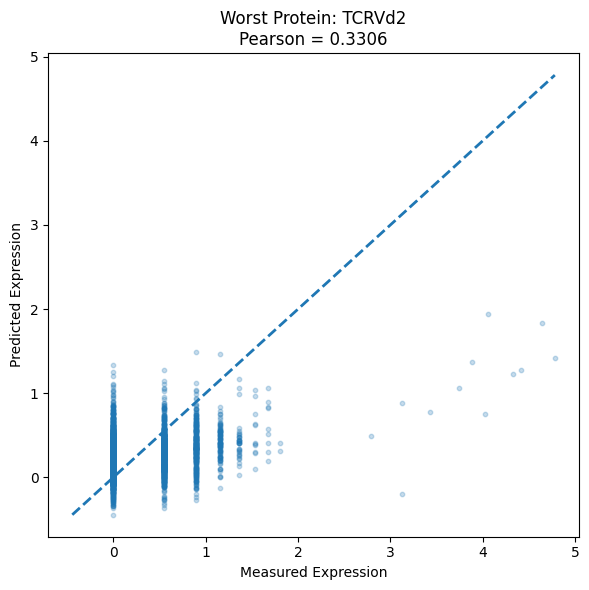

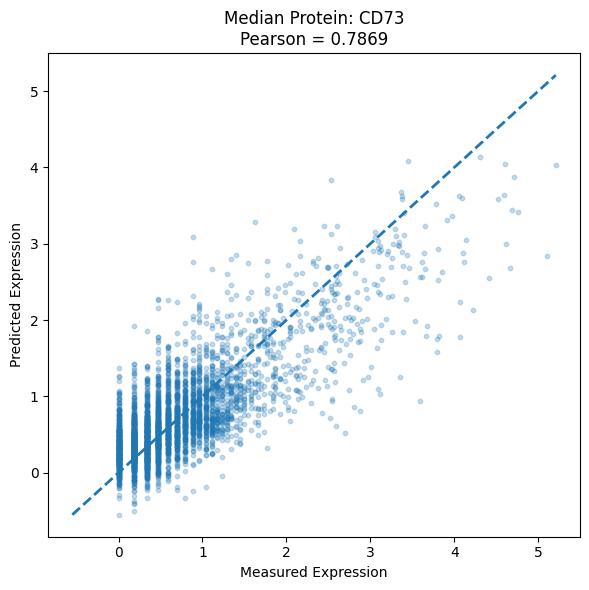

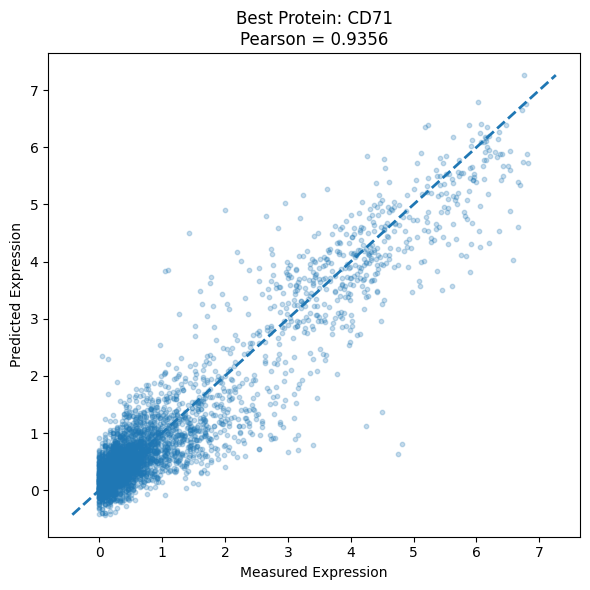

In [20]:
for label, idx in zip(labels, selected_idx):

    x = y_test[:, idx]
    yhat = y_pred[:, idx]

    plt.figure(figsize=(6,6))

    plt.scatter(
        x,
        yhat,
        s=10,
        alpha=0.25
    )

    mn = min(x.min(), yhat.min())
    mx = max(x.max(), yhat.max())

    plt.plot([mn, mx], [mn, mx], "--", linewidth=2)

    plt.xlabel("Measured Expression")
    plt.ylabel("Predicted Expression")

    plt.title(
        f"{label} Protein: {protein_names[idx]}\n"
        f"Pearson = {pearson_per_protein[idx]:.4f}"
    )

    plt.tight_layout()
    plt.show()

In [21]:
from pathlib import Path
import numpy as np

save_path = Path("/content/drive/MyDrive/gp/data/GP_datasets/results")
save_path.mkdir(parents=True, exist_ok=True)

model_name = "Transcriptformer"  # change per notebook

np.savez(
    save_path / f"{model_name}_bone_marrow_protein_results.npz", # change dataset name

    # raw outputs
    y_test=y_test,
    y_pred=y_pred,

    # metadata
    protein_names=protein_names,

    # metrics
    pearson_per_protein=pearson_per_protein,

    # selected indices (diagnostic)
    worst_idx=worst_idx,
    median_idx=median_idx,
    best_idx=best_idx,

    selected_idx=np.array(selected_idx),

    mean_pearson=np.nanmean(pearson_per_protein),
)

print(f"Saved results for {model_name} at:", save_path)

Saved results for Transcriptformer at: /content/drive/MyDrive/gp/data/GP_datasets/results


# CBMC dataset protein expression predicition

In [ ]:
!mkdir -p /content/drive/MyDrive/gp/transcriptformer/transcriptformer/pep/cbmc

In [ ]:
cbmc_dir='/content/drive/MyDrive/gp/transcriptformer/transcriptformer/pep/cbmc'

## Data preprocessing

In [ ]:
cbmc_data_path = os.path.join(data_dir, "GP_datasets/CBMC/cbmc_rna_filtered.h5ad")
adata = sc.read_h5ad(cbmc_data_path)


In [ ]:
adata_adt=sc.read_h5ad(os.path.join(data_dir, "GP_datasets/CBMC/cbmc_adt.h5ad"))

In [ ]:
adata

AnnData object with n_obs × n_vars = 8617 × 19626
    obs: 'size_factors'
    var: 'n_counts', 'feature_name', 'hvg', 'hvg_score', 'gene_symbols'
    uns: '_from_cache', 'data_reference', 'data_url', 'dataset_description', 'dataset_id', 'dataset_name', 'dataset_organism', 'dataset_reference', 'dataset_summary', 'dataset_url', 'normalization_id', 'var_names_all'
    obsm: 'X_svd', 'mode2'
    layers: 'counts', 'normalized'

In [ ]:
import mygene

mg = mygene.MyGeneInfo()

# Use the clean gene_symbols column, not the index
gene_symbols = adata.var['gene_symbols'].tolist()

# Query Ensembl IDs
result = mg.querymany(gene_symbols, scopes='symbol', fields='ensembl.gene', species='human')

# Build mapping: clean symbol → Ensembl ID
symbol_to_ensembl = {}
for r in result:
    if 'ensembl' in r:
        ensembl = r['ensembl']
        if isinstance(ensembl, list):
            symbol_to_ensembl[r['query']] = ensembl[0]['gene']
        else:
            symbol_to_ensembl[r['query']] = ensembl['gene']

# Map via gene_symbols column (not the index)
adata.var['ensembl_id'] = adata.var['gene_symbols'].map(symbol_to_ensembl)

# Check mapping rate
print(f"Mapped: {adata.var['ensembl_id'].notna().sum()} / {len(adata.var)}")
print(adata.var[['gene_symbols', 'ensembl_id']].head(10))

INFO:biothings.client:querying 1-1000 ...
INFO:biothings.client:querying 1001-2000 ...
INFO:biothings.client:querying 2001-3000 ...
INFO:biothings.client:querying 3001-4000 ...
INFO:biothings.client:querying 4001-5000 ...
INFO:biothings.client:querying 5001-6000 ...
INFO:biothings.client:querying 6001-7000 ...
INFO:biothings.client:querying 7001-8000 ...
INFO:biothings.client:querying 8001-9000 ...
INFO:biothings.client:querying 9001-10000 ...
INFO:biothings.client:querying 10001-11000 ...
INFO:biothings.client:querying 11001-12000 ...
INFO:biothings.client:querying 12001-13000 ...
INFO:biothings.client:querying 13001-14000 ...
INFO:biothings.client:querying 14001-15000 ...
INFO:biothings.client:querying 15001-16000 ...
INFO:biothings.client:querying 16001-17000 ...
INFO:biothings.client:querying 17001-18000 ...
INFO:biothings.client:querying 18001-19000 ...
INFO:biothings.client:querying 19001-19626 ...
INFO:biothings.client:Finished.
INFO:biothings.client:Pass "returnall=True" to ret

Mapped: 14718 / 19626
               gene_symbols       ensembl_id
HUMAN_A1BG             A1BG  ENSG00000121410
HUMAN_A1BG-AS1     A1BG-AS1  ENSG00000268895
HUMAN_A1CF             A1CF  ENSG00000148584
HUMAN_A2M               A2M  ENSG00000175899
HUMAN_A2M-AS1       A2M-AS1  ENSG00000245105
HUMAN_A2ML1           A2ML1  ENSG00000166535
HUMAN_A4GALT         A4GALT  ENSG00000128274
HUMAN_A4GNT           A4GNT  ENSG00000118017
HUMAN_AAAS             AAAS  ENSG00000291836
HUMAN_AACS             AACS  ENSG00000081760


In [ ]:
adata.obs['assay']='10x Genomics'

In [ ]:
adata

AnnData object with n_obs × n_vars = 8617 × 19626
    obs: 'size_factors', 'assay'
    var: 'n_counts', 'feature_name', 'hvg', 'hvg_score', 'gene_symbols', 'ensembl_id'
    uns: '_from_cache', 'data_reference', 'data_url', 'dataset_description', 'dataset_id', 'dataset_name', 'dataset_organism', 'dataset_reference', 'dataset_summary', 'dataset_url', 'normalization_id', 'var_names_all'
    obsm: 'X_svd', 'mode2'
    layers: 'counts', 'normalized'

In [ ]:
adata.write(os.path.join(cbmc_dir, "cbmc_transcriptformer.h5ad"))

## Get embeddings

In [ ]:
data=os.path.join(cbmc_dir, 'cbmc_transcriptformer.h5ad')
embeddings_dir="/content/drive/MyDrive/gp/transcriptformer/transcriptformer/pep/cbmc"

In [ ]:
!transcriptformer inference --help

usage: transcriptformer inference [-h] --checkpoint-path CHECKPOINT_PATH
                                  --data-file DATA_FILE
                                  [--output-path OUTPUT_PATH]
                                  [--output-filename OUTPUT_FILENAME]
                                  [--batch-size BATCH_SIZE]
                                  [--gene-col-name GENE_COL_NAME]
                                  [--precision {16-mixed,32}]
                                  [--pretrained-embedding PRETRAINED_EMBEDDING]
                                  [--clip-counts CLIP_COUNTS]
                                  [--filter-to-vocabs]
                                  [--model-type {transcriptformer,esm2ce}]
                                  [--use-raw USE_RAW] [--emb-type {cell,cge}]
                                  [--remove-duplicate-genes]
                                  [--num-gpus NUM_GPUS]
                                  [--device {auto,cpu,cuda,mps}]
                   

In [ ]:
!transcriptformer inference \
    --checkpoint-path {model_dir} \
    --data-file {data} \
    --output-path {embeddings_dir} \
    --batch-size 8 \
    --remove-duplicate-genes \
    --gene-col-name ensembl_id \
    --output-filename transcriptformer_cbmc_embeddings.h5ad



 ___________  ___   _   _  _____           _       _  ______ ______________  ___ ___________
|_   _| ___ \/ _ \ | \ | |/  ___|         (_)     | | |  ___|  _  | ___ \  \/  ||  ___| ___ \
  | | | |_/ / /_\ \|  \| |\ `--.  ___ _ __ _ _ __ | |_| |_  | | | | |_/ / .  . || |__ | |_/ /
  | | |    /|  _  || . ` | `--. \/ __| '__| | '_ \| __|  _| | | | |    /| |\/| ||  __||    /
  | | | |\ \| | | || |\  |/\__/ / (__| |  | | |_) | |_| |   \ \_/ / |\ \| |  | || |___| |\ \
  \_/ \_| \_\_| |_/\_| \_/\____/ \___|_|  |_| .__/ \__\_|    \___/\_| \_\_|  |_/\____/\_| \_|
                                            | |
                                            |_|

2026-05-01 21:52:13,202 - INFO - Loading vocabulary file: /content/drive/MyDrive/gp/transcriptformer/transcriptformer/transcriptformer/tf_exemplar/vocabs/assay
2026-05-01 21:52:14,179 - INFO - Loading ESM2 mappings from /content/drive/MyDrive/gp/transcriptformer/transcriptformer/transcriptformer/tf_exemplar/vocabs
2026-05-01 21:53:00,676 -

In [ ]:
adata = sc.read_h5ad(os.path.join(embeddings_dir,"transcriptformer_cbmc_embeddings.h5ad"))


In [ ]:
adata

AnnData object with n_obs × n_vars = 8617 × 0
    obs: 'size_factors', 'assay'
    obsm: 'embeddings'

In [ ]:
adata.obsm['embeddings']

array([[-0.04842066,  0.18822911,  0.00522039, ...,  0.06112321,
         0.07364332,  0.16383487],
       [ 0.02902438,  0.19427279, -0.03587573, ..., -0.17510015,
         0.12044776,  0.11738112],
       [-0.05972087,  0.24990217,  0.00470887, ...,  0.13167404,
         0.11803839,  0.19574904],
       ...,
       [ 0.05393633,  0.14066929,  0.03420313, ..., -0.18229997,
         0.00859292,  0.12025576],
       [-0.01237657,  0.1180879 ,  0.08713151, ..., -0.21574126,
        -0.00274801,  0.10322059],
       [ 0.00797622,  0.15616922,  0.04546642, ..., -0.08443926,
         0.06715345,  0.03410512]], dtype=float32)

In [ ]:
adata.obsm['X_transcriptformer'] = adata.obsm.pop('embeddings')


In [ ]:
adata.write(os.path.join(embeddings_dir,"transcriptformer_cbmc_embeddings.h5ad"))

## Regression

In [23]:
embeddings_dir="/content/drive/MyDrive/gp/transcriptformer/pep/cbmc"
adata = sc.read_h5ad(os.path.join(embeddings_dir,"transcriptformer_cbmc_embeddings.h5ad"))
adata_adt = sc.read_h5ad(os.path.join(data_dir, "GP_datasets/CBMC/cbmc_adt.h5ad"))

In [24]:
adata

AnnData object with n_obs × n_vars = 8617 × 0
    obs: 'size_factors', 'assay'
    obsm: 'X_transcriptformer'

In [25]:
adata_adt

AnnData object with n_obs × n_vars = 8617 × 13
    var: 'feature_name', 'hvg', 'hvg_score'
    uns: 'data_reference', 'data_url', 'dataset_description', 'dataset_id', 'dataset_name', 'dataset_organism', 'dataset_reference', 'dataset_summary', 'dataset_url', 'normalization_id'
    obsm: 'X_svd'
    layers: 'counts', 'normalized'

In [26]:
X = adata.obsm['X_transcriptformer']
y=adata_adt.layers['normalized']

X = X.toarray() if hasattr(X, "toarray") else X
y = y.toarray() if hasattr(y, "toarray") else y

In [27]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)

model = LinearRegression()
mse_scores = []

for train_idx, test_idx in kf.split(X):
    X_train, X_test = X[train_idx], X[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

In [28]:
# per-protein MSE and rMSE
mse_per_protein = ((y_test - y_pred) ** 2).mean(axis=0)
rmse_per_protein = np.sqrt(mse_per_protein)

# overall mean
avg_mse = mse_per_protein.mean()
avg_rmse = rmse_per_protein.mean()


In [29]:
pearson_per_protein = []

for i in range(y_test.shape[1]):
    if np.std(y_test[:, i]) > 0 and np.std(y_pred[:, i]) > 0:
        corr, _ = pearsonr(y_test[:, i], y_pred[:, i])
    else:
        corr = np.nan
    pearson_per_protein.append(corr)

pearson_per_protein = np.array(pearson_per_protein)
mean_pearson = np.nanmean(pearson_per_protein)

spearman_per_protein = []

for i in range(y_test.shape[1]):
    if np.std(y_test[:, i]) > 0 and np.std(y_pred[:, i]) > 0:
        corr, _ = spearmanr(y_test[:, i], y_pred[:, i])
    else:
        corr = np.nan
    spearman_per_protein.append(corr)

spearman_per_protein = np.array(spearman_per_protein)
mean_spearman = np.nanmean(spearman_per_protein)

In [30]:
# per-protein MSE
mse_per_protein = ((y_test - y_pred) ** 2).mean(axis=0)

# overall mean
avg_mse = mse_per_protein.mean()

print("Avg MSE:", avg_mse)
print("Per-protein MSE:", mse_per_protein)
print("Per-protein MSE shape:", mse_per_protein.shape)

Avg MSE: 0.12939532
Per-protein MSE: [0.10667416 0.09224074 0.4715521  0.13009374 0.14718166 0.09342459
 0.09746746 0.10020209 0.07721002 0.08441814 0.10593385 0.09378742
 0.08195305]
Per-protein MSE shape: (13,)


In [31]:
print("Avg MSE:", avg_mse)
# print("Per-protein MSE:", mse_per_protein)
# print("Per-protein MSE shape:", mse_per_protein.shape)


print("Avg RMSE:", avg_rmse)
# print("Per-protein RMSE:", rmse_per_protein)
# print("Per-protein RMSE shape:", rmse_per_protein.shape)

Avg MSE: 0.12939532
Avg RMSE: 0.34478128


In [32]:
print("Avg Pearson correlation:", mean_pearson)
# print("Per-protein Pearson correlation:", pearson_per_protein)
# print("Per-protein Pearson shape:", pearson_per_protein.shape)

print("Mean Spearman correlation:", mean_spearman)
# print("Per-protein Spearman correlation:", spearman_per_protein)
# print("Per-protein Spearman shape:", spearman_per_protein.shape)

Avg Pearson correlation: 0.7276771
Mean Spearman correlation: 0.6024684361779972


In [33]:
valid_idx = np.where(~np.isnan(pearson_per_protein))[0]
valid_scores = pearson_per_protein[valid_idx]

sorted_idx = valid_idx[np.argsort(valid_scores)]

worst_idx = sorted_idx[0]
median_idx = sorted_idx[len(sorted_idx)//2]
best_idx = sorted_idx[-1]

selected_idx = [worst_idx, median_idx, best_idx]
labels = ["Worst", "Median", "Best"]

protein_names = np.array(adata_adt.var_names)

print("\nSelected proteins:")
for label, idx in zip(labels, selected_idx):
    print(
        f"{label}: {protein_names[idx]} "
        f"(Pearson = {pearson_per_protein[idx]:.4f})"
    )


Selected proteins:
Worst: CCR7 (Pearson = 0.4226)
Median: CD16 (Pearson = 0.7843)
Best: CD3 (Pearson = 0.9276)


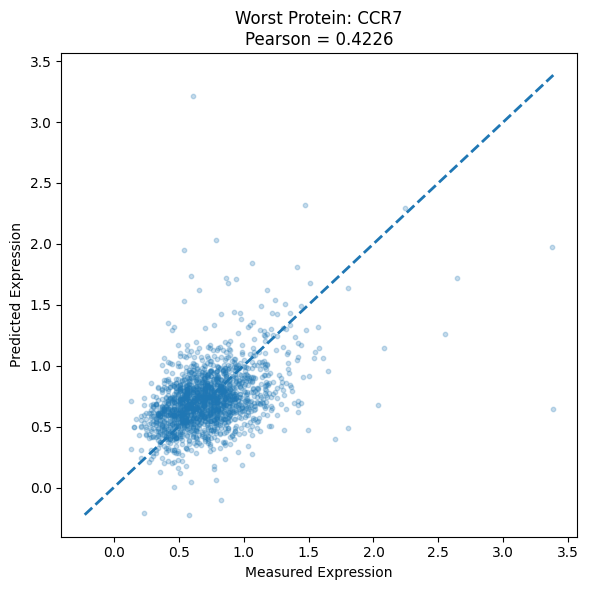

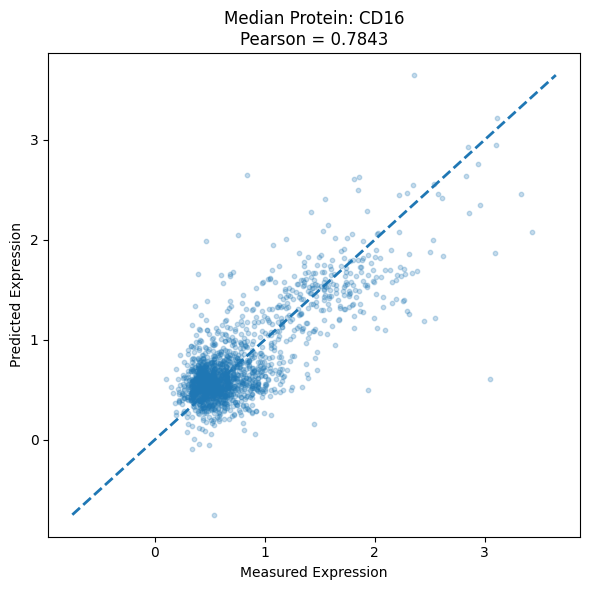

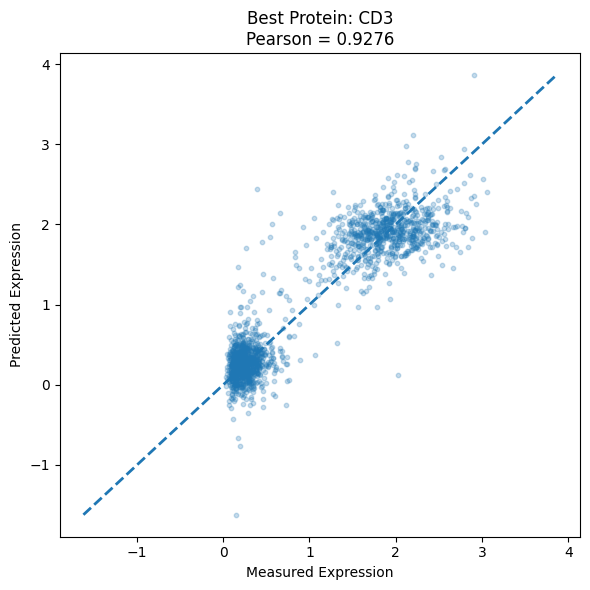

In [34]:
for label, idx in zip(labels, selected_idx):

    x = y_test[:, idx]
    yhat = y_pred[:, idx]

    plt.figure(figsize=(6,6))

    plt.scatter(
        x,
        yhat,
        s=10,
        alpha=0.25
    )

    mn = min(x.min(), yhat.min())
    mx = max(x.max(), yhat.max())

    plt.plot([mn, mx], [mn, mx], "--", linewidth=2)

    plt.xlabel("Measured Expression")
    plt.ylabel("Predicted Expression")

    plt.title(
        f"{label} Protein: {protein_names[idx]}\n"
        f"Pearson = {pearson_per_protein[idx]:.4f}"
    )

    plt.tight_layout()
    plt.show()

In [36]:
from pathlib import Path
import numpy as np

save_path = Path("/content/drive/MyDrive/gp/data/GP_datasets/results")
save_path.mkdir(parents=True, exist_ok=True)

model_name = "Transcriptformer"  # change per notebook

np.savez(
    save_path / f"{model_name}_CBMCs_protein_results.npz", # change dataset name

    # raw outputs
    y_test=y_test,
    y_pred=y_pred,

    # metadata
    protein_names=protein_names,

    # metrics
    pearson_per_protein=pearson_per_protein,

    # selected indices (diagnostic)
    worst_idx=worst_idx,
    median_idx=median_idx,
    best_idx=best_idx,

    selected_idx=np.array(selected_idx),

    mean_pearson=np.nanmean(pearson_per_protein),
)

print(f"Saved results for {model_name} at:", save_path)

Saved results for Transcriptformer at: /content/drive/MyDrive/gp/data/GP_datasets/results
